# Parameter estimation for translational protein sector
This notebook was used to estimate the parameters for the translational protein sector as used in the revised proteome allocation model. This notebook has been created to establish the parameters for *Saccharomyces cerevisiae* CEN.PK-117D. The initial parameters were already established by [Pranas Grigaitis](https://pranasag.github.io/) in [Elsemman et al (2021)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8831649/) (caption in Figure S10, suplementary text S2.3).

**Author: Samira L. van den Bogaard**

### Setting up the notebook environment

In [1]:
#package
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if os.path.split(os.getcwd())[1] == 'Yeast9':
    os.chdir('../../..')
    
from PAModelpy import Config

from Scripts.pam_generation_uniprot_id import set_up_ecoli_pam as setup_yeast_pam
from Scripts.pam_generation_uniprot_id import set_up_yeast_config

from Modules.utils.sector_config_functions import (perform_linear_regression,
                                                                        reset_translational_sector,
                                                                        plot_translational_protein_vs_mu,
                                                                        get_model_simulations_vs_sector,
                                                  )

Loading PAModelpy modules version 0.0.3.15
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


In [2]:
#constants
#files and file paths
DATA_FILE_PATH = os.path.join('Data', 'Scerevisiae_phenotypes', 'Proteome',
                              'Elsemman2021_quant_proteomics_scerevisiaecenpk.xlsx')
FUNCTIONAL_ANNOTATION_FILE_PATH =os.path.join('Data', 'Scerevisiae_phenotypes', 'Proteome',
                                              'TableS1_elsemman-etal2021_functional-annotation.xls')
PAM_DATA_FILE_PATH = os.path.join('Data', 'proteinAllocationModel_yeast9_EnzymaticData_240903.xlsx')
VALID_DATA_FILE_PATH = os.path.join('Data', 'Ecoli_phenotypes', 'Scerevisiae_phenotypes.xlsx')
RESULT_FIG_PATH = os.path.join('Figures', 'SuppFig1_translational_sector_Scerevisiae.png')

#data parsing
PROTEIN_FRACTION_AE_UE = 0.6809 #[g_prot/g_prot] as published in Elsemman et al (2021) Table S7
PROTEIN_FRACTION_0 = 0.3888 #[g_prot/g_cdw] as published in Elsemman et al (2021) Table S1
PROTEIN_FRACTION_MU = 0.4854 #[g_prot/g_cdw/h] as published in Elsemman et al (2021) Table S1

MEASURED_PROTEIN_FRACTION = 1#not mentioned in Elsemman et al 2021 
#0.55*0.55#0.55 * 0.55 #measured proteome vs g_p/gcdw in Ecoli
GLC_UPTAKE_RXN_ID = 'r_1714'
BIOMASS_RXN_ID = 'r_2111'
MW_GLC = 180.15588 #g/mol

### Configure parameters and data
To establish the relation between translational protein and substrate uptake rate we use the relation between translational protein and growth rate from the data from [Elsemman et al (2021)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8831649/). For that we set up the model with the sector constraints by [Alter et al. (2021)](https://journals.asm.org/doi/10.1128/mSystems.00625-20) and let it run without total protein constraint. This way we obtain a relationship between the translational protein and substrate uptake rate: the translational protein sector is determined by the relation to growth as published by [Elsemman et al (2021)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8831649/) and the substrate uptake rate corresponding to the specific growth rate are predicted by the model. Because the relationship between growth and translational protein might cease when the *S. cerevisiae* cells are entering overflow metabolism, we do not use the datapoints in the dataset from [Elsemman et al (2021)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8831649/) which belong to growth rates in the overflow regime.

In [3]:
#set up model without total protein constraint to just model the linear relation between
pamodel = setup_yeast_pam(pam_info_file = PAM_DATA_FILE_PATH, model = 'yeast9.xml', config = set_up_yeast_config(),
                          total_protein=False, active_enzymes = False, unused_enzymes = False,
                          sensitivity = False) # sensitivity disabled to speed things up
#get parameters
translational_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')
tps_molmass = translational_sector.mol_mass[0]

Setting up the proteome allocation model yeastGEM_v9__46__0__46__1

Total condition-dependent protein constraint is not added 

Add the following protein sector: TranslationalProteinSector

Done with setting up the proteome allocation model yeastGEM_v9__46__0__46__1



### Get the proteomics data and parse it to long format

First get the proteomics data

In [4]:
#get the validation data
df_proteomics_wide = pd.read_excel(DATA_FILE_PATH, sheet_name='proteome').drop('Majority protein IDs', axis=1)

#convert to long format
df_proteomics_long = pd.melt(df_proteomics_wide, id_vars= 'Protein', 
                             var_name = 'experiment', value_name='protein_fraction')
#remove 0.3A and 0.3B from dilution rates

Map the proteomics data to the corresponding function and find the proteome fraction for the translational sector

In [5]:
#map the proteomics data to the functional annotation
funct_annotation = pd.read_excel(FUNCTIONAL_ANNOTATION_FILE_PATH)[['Protein', 'Pathway']]
df_proteomics_mapped = pd.merge(df_proteomics_long, funct_annotation, how = 'left', on='Protein').dropna(
    subset='Pathway')

df_proteomics_mapped

,Protein,experiment,protein_fraction,Pathway
0,Q0045,0.2,0.000188,Oxidative phosphorylation
2,Q0140,0.2,0.000039,Mitochondrial ribosome
3,Q0250,0.2,0.000775,Oxidative phosphorylation
4,YAL003W,0.2,0.003258,Translation elongation factors
6,YAL012W,0.2,0.001517,Amino acid biosynthesis
...,...,...,...,...
25467,YPL214C,0.34,NaN,Cofactor biosynthesis
25470,YPL224C,0.34,NaN,Mitochondrial carriers
25481,YPR021C,0.34,NaN,Mitochondrial carriers
25501,YPR144C,0.34,NaN,Ribosome assembly factors


In [6]:
translation_per_experiment = {}
for experiment, proteomics_data in df_proteomics_mapped.groupby('experiment'):
    transl_fraction = proteomics_data[
        proteomics_data.Pathway.str.contains('translation|ribosome', case=False, regex=True)
    ].groupby('Pathway').sum().sum().iloc[0]
    translation_per_experiment[experiment] = transl_fraction


/tmp/ipykernel_276656/2039814473.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ].groupby('Pathway').sum().sum().iloc[0]
/tmp/ipykernel_276656/2039814473.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ].groupby('Pathway').sum().sum().iloc[0]
/tmp/ipykernel_276656/2039814473.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ].groupby('Pathway').sum().sum().iloc[0]
/tmp/ipykernel_276656/2039814473.py:5: FutureW

filter the range of growth rates for those who are nor influenced by more complex metabolic processes (low growth or overflow metabolism). Because of limited data in the respiratory regime, one datapoint on the edge with overflow (0.27 h-1) was also included

In [7]:
#filter the range of growth rates for those who are nor influenced by more complex metabolic processes, such as:

#find dilution rate for experiments, only have to change the replicates for 0.3 h-1 (denoted by A and B)
df_proteomics_mapped['dilution_rate'] = [d if isinstance(d, float) else 0.3 for d in df_proteomics_mapped['experiment']]
#stationary growth
df_proteomics_resp = df_proteomics_mapped[df_proteomics_mapped['dilution_rate']>0.1]
#overflow metabolism
df_proteomics_resp = df_proteomics_resp[
    (df_proteomics_resp['dilution_rate']<0.3)
]

The slope and intercept are derived from proteome measurements. We know these measurement are related to a total protein concentration of 0.32 g/g_cdw. This is why we need to correct the slope and intercept when it it incorporated into the model.

In [8]:
#get the relation with growth rate
def get_g_protein_per_g_cdw(mu):
    return PROTEIN_FRACTION_0 + PROTEIN_FRACTION_MU*mu

slope, intercept = perform_linear_regression(x=df_proteomics_resp['dilution_rate'], 
                                             y=[
                                                 translation_per_experiment[d]/get_g_protein_per_g_cdw(d) \
                                                 for d in df_proteomics_resp['dilution_rate']
                                             ])

print('Translational sector vs growth rate using data from Schmidt et al (2016): \n Intercept: ',intercept*MEASURED_PROTEIN_FRACTION, 'g/g_cdw')
print('Slope: ',slope*MEASURED_PROTEIN_FRACTION, 'g/g_cdw/h')

Translational sector vs growth rate using data from Schmidt et al (2016): 
 Intercept:  0.30853035500701553 g/g_cdw
Slope:  0.4425584652750507 g/g_cdw/h


### Use the mu vs translational protein relationship to perform simulations with the PAM model
The predicted glucose uptake rates can be used to derive the relationship between glucose uptake and translational protein.

In [9]:
#adjust relation in model
trans_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')

#adjust the translational protein sector
pamodel.change_sector_parameters(trans_sector, slope*MEASURED_PROTEIN_FRACTION,
                                 intercept*MEASURED_PROTEIN_FRACTION, lin_rxn_id = BIOMASS_RXN_ID)

In [10]:
#run the model
substrate_range = np.arange(-15,1,1)

#we shouldn't correct for measured total protein here, as we are comparing it to the measured data
simulation_results_bms = get_model_simulations_vs_sector(pamodel, GLC_UPTAKE_RXN_ID, BIOMASS_RXN_ID,
                                           substrate_range, intercept,slope) 


Running simulations with  -15 mmol/g_cdw/h of substrate going into the system
Running simulations with  -14 mmol/g_cdw/h of substrate going into the system
Running simulations with  -13 mmol/g_cdw/h of substrate going into the system
Running simulations with  -12 mmol/g_cdw/h of substrate going into the system
Running simulations with  -11 mmol/g_cdw/h of substrate going into the system
Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -7 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the 

/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [11]:
#derive the relation to glucose uptake rate
#results are in g_transprot/g_prot and need to be converted to g/gcdw (glucose uptake should stay in mmol for compatibility with model)
slope_glc, intercept_glc = perform_linear_regression(
    x=simulation_results_bms[GLC_UPTAKE_RXN_ID], y=simulation_results_bms['translational_protein'])

print('Translational sector vs glucose uptake using data from Schmidt et al (2016): \n Intercept: ',intercept_glc *MEASURED_PROTEIN_FRACTION, ' g/g_cdw')
print('Slope: ',slope_glc*MEASURED_PROTEIN_FRACTION, ' g/mmol_glucose/h')


Translational sector vs glucose uptake using data from Schmidt et al (2016): 
 Intercept:  0.30709117212614484  g/g_cdw
Slope:  -0.039458282642389146  g/mmol_glucose/h


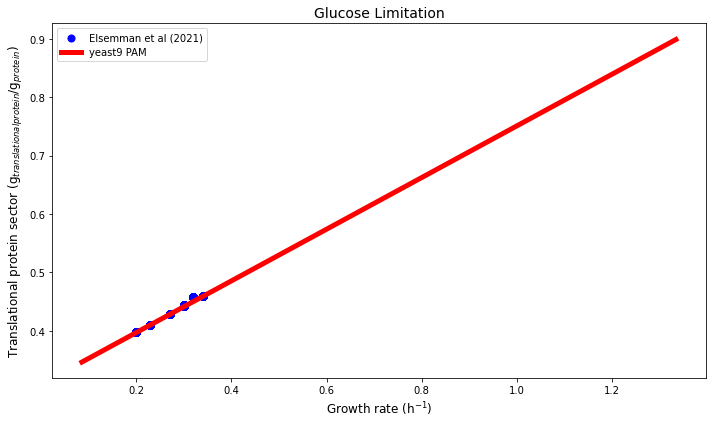

In [25]:
elsemman_translation = pd.DataFrame({'Experimental Growth rate': df_proteomics_mapped['dilution_rate'],
        'Translation, ribosomal structure and biogenesis':[
                                                 translation_per_experiment[exp]/get_g_protein_per_g_cdw(d)*100 \
                                                 for exp, d in zip(df_proteomics_mapped['experiment'], df_proteomics_mapped['dilution_rate'])
                                             ]}) # *100, because there is a convesion from percentage to fraction in the plotting function

#visualization of results
plot_translational_protein_vs_mu(elsemman_translation, simulation_results_bms, 
                                 protein_fraction = 1, 
                                 measured_protein_fraction=1,
                                 oxygen_results = None, 
                                 configuration=set_up_yeast_config(),
                                 literature_label = 'Elsemman et al (2021)', model_label = 'yeast9 PAM')

### Use the glucose vs translational protein relationship to perform simulations with the PAM model with only the translational protein sector

In [20]:
#make a model with only translational protein sector
pamodel_transl = setup_yeast_pam(pam_info_file = PAM_DATA_FILE_PATH, model = 'yeast9.xml', 
                                 config = set_up_yeast_config(),
                                 total_protein=False, 
                                 active_enzymes = False, unused_enzymes = False,
                                 sensitivity = False
                                ) # sensitivity disabled to speed things up

#adjust the translational protein sector
# pamodel_transl = reset_translational_sector(pamodel_transl, slope_glc*MEASURED_PROTEIN_FRACTION, 
#                                             intercept_glc*MEASURED_PROTEIN_FRACTION, new_id = GLC_UPTAKE_RXN_ID)
trans_sector = pamodel_transl.sectors.get_by_id('TranslationalProteinSector')

pamodel_transl.change_sector_parameters(trans_sector, slope_glc*MEASURED_PROTEIN_FRACTION,
                                 intercept_glc*MEASURED_PROTEIN_FRACTION, 
                                        lin_rxn_id = GLC_UPTAKE_RXN_ID)

Setting up the proteome allocation model yeastGEM_v9__46__0__46__1

Total condition-dependent protein constraint is not added 

Add the following protein sector: TranslationalProteinSector

Done with setting up the proteome allocation model yeastGEM_v9__46__0__46__1



In [21]:
simulation_results_glc = get_model_simulations_vs_sector(pamodel_transl, GLC_UPTAKE_RXN_ID, GLC_UPTAKE_RXN_ID,
                                           substrate_range, intercept_glc, slope_glc, to_save = BIOMASS_RXN_ID)

Running simulations with  -15 mmol/g_cdw/h of substrate going into the system
Running simulations with  -14 mmol/g_cdw/h of substrate going into the system
Running simulations with  -13 mmol/g_cdw/h of substrate going into the system
Running simulations with  -12 mmol/g_cdw/h of substrate going into the system
Running simulations with  -11 mmol/g_cdw/h of substrate going into the system
Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -7 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the 

/home/samiralvdb/.local/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


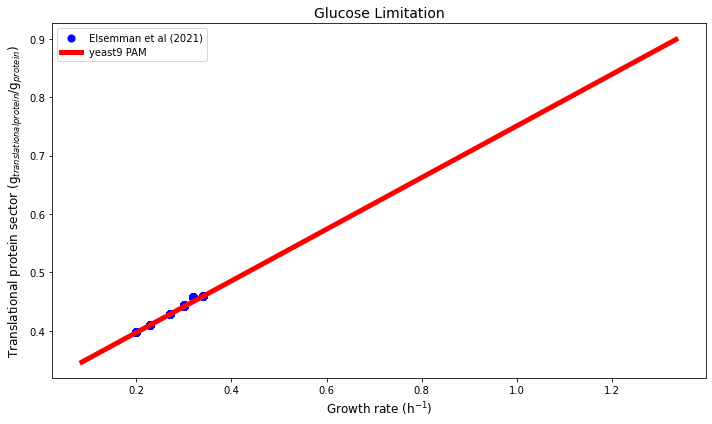

In [26]:
#visualize results
plot_translational_protein_vs_mu(elsemman_translation, simulation_results_glc, 
                                 protein_fraction = 1, 
                                 measured_protein_fraction=1,
                                 oxygen_results = None, 
                                 configuration=set_up_yeast_config(),
                                 literature_label = 'Elsemman et al (2021)', model_label = 'yeast9 PAM')

### Save the resulting parameters

In [29]:
# Get the information about the enzyme sectors
translational_protein_df = pd.DataFrame({'Parameter': ['id_list', 'tps_0', 'tps_mu', 'mol_mass'],
                                        'Value': ['r_1714', intercept_glc *MEASURED_PROTEIN_FRACTION,
                                                  slope_glc *MEASURED_PROTEIN_FRACTION, 1388.488*1e3],
                                        'Unit': ['', 'g_ribosome/g_cdw', 'g_ribosome/mmol_glucose/h', '𝑔/𝑚𝑜𝑙'],
                                        'Description': ['glucose uptake rate', 'derived using Elsemman et al 2021 (Fig S10)',
                                                       'derived using Elsemman et al 2021 (Fig S10)',
                                                        'derived using Elsemman et al 2021 (Fig S10)']})

with pd.ExcelWriter(PAM_DATA_FILE_PATH, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    translational_protein_df.to_excel(writer, sheet_name='Translational', index =False)